# Algorithmic Trading Strategy: Predicting AAPL Stock Direction

### **1. Project Objective**
The goal of this project is to develop and evaluate a machine learning-based trading strategy for Apple Inc. (AAPL) stock. We aim to predict the daily direction of the stock (**Up** or **Down**) to generate profitable buy/sell signals.

### **2. Methodology**
Our approach involves three key steps:
* **Feature Engineering:** Calculating technical indicators (RSI, Moving Averages, Volatility) to capture market momentum.
* **Modeling:** Comparing three distinct algorithms:
    * *Decision Tree* (Baseline)
    * *Random Forest* (Ensemble Method)
    * *Markov Chain* (Probabilistic Model)
* **Backtesting:** Simulating a trading strategy to measure real-world performance (Equity Curve, ROI) and risk management.

### **3. Tech Stack**
* **Data:** `yfinance` (Yahoo Finance API)
* **Analysis:** `pandas`, `numpy`, `ta` (Technical Analysis Library)
* **Machine Learning:** `scikit-learn`
* **Visualization:** `matplotlib`, `seaborn`

In [35]:
# Note: If running this notebook for the first time, uncomment and run:
# !pip install yfinance ta


import pandas as pd
import numpy as np
import yfinance as yf 
import ta 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

# System settings
import warnings
warnings.filterwarnings('ignore') 

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')


plt.style.use("seaborn-v0_8")  

# Download historical data
ticker = "AAPL"
data = yf.download(ticker, start="2020-01-01", end="2025-12-31")
data.reset_index(inplace=True)   # Reset index to restore 'Date' as a normal column

data.columns = [col[0] for col in data.columns]   # Flatten MultiIndex to clean column names

from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score
import numpy as np
import pandas as pd

[*********************100%***********************]  1 of 1 completed


In [36]:
data.head()  # Display the first 5 rows of the dataframe

,Date,Close,High,Low,Open,Volume
0,2020-01-02,72.468262,72.528582,71.223259,71.476600,135480400
1,2020-01-03,71.763725,72.523754,71.539337,71.696167,146322800
2,2020-01-06,72.335571,72.374177,70.634554,70.885487,118387200
3,2020-01-07,71.995354,72.600960,71.775789,72.345204,108872000
4,2020-01-08,73.153496,73.455095,71.698581,71.698581,132079200


In [37]:
data.columns  

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [38]:
data.describe() # Display descriptive statistics for the dataset

,Date,Close,High,Low,Open,Volume
count,1501,1501.000000,1501.000000,1501.000000,1501.000000,1.501000e+03
mean,2022-12-25 13:49:50.806129152,164.438873,166.124394,162.584584,164.277267,8.481244e+07
min,2020-01-02 00:00:00,54.264339,55.263190,51.420161,55.161612,2.013560e+07
25%,2021-06-29 00:00:00,131.339401,132.691276,129.994106,131.631927,5.101130e+07
50%,2022-12-22 00:00:00,163.121536,165.042207,161.727451,163.045409,7.046270e+07
75%,2024-06-24 00:00:00,196.107971,198.272565,193.757442,195.571683,1.008271e+08
max,2025-12-19 00:00:00,286.190002,288.619995,283.299988,286.200012,4.265100e+08
std,NaN,49.284739,49.582492,48.931689,49.240051,5.132370e+07


In [39]:
data.isnull().any() # Check for missing values (NaN) to ensure the dataset is complete

Date      False
Close     False
High      False
Low       False
Open      False
Volume    False
dtype: bool

In [40]:
data["Target"] = (data["Close"].shift(-1) > data["Close"]).astype(int) # Target = trend (1 if Up, 0 if Down)

In [41]:
print (data)

           Date       Close        High         Low        Open     Volume  \
0    2020-01-02   72.468262   72.528582   71.223259   71.476600  135480400   
1    2020-01-03   71.763725   72.523754   71.539337   71.696167  146322800   
2    2020-01-06   72.335571   72.374177   70.634554   70.885487  118387200   
3    2020-01-07   71.995354   72.600960   71.775789   72.345204  108872000   
4    2020-01-08   73.153496   73.455095   71.698581   71.698581  132079200   
...         ...         ...         ...         ...         ...        ...   
1496 2025-12-15  274.109985  280.149994  272.839996  280.149994   50409100   
1497 2025-12-16  274.609985  275.500000  271.790009  272.820007   37648600   
1498 2025-12-17  271.839996  276.160004  271.640015  275.010010   50138700   
1499 2025-12-18  272.190002  273.630005  266.950012  273.609985   51630700   
1500 2025-12-19  273.670013  274.600006  269.899994  272.149994  144599200   

      Target  
0          0  
1          1  
2          0  
3  

In [42]:
data["Return"] = data["Close"].pct_change() # Calculate daily returns
data["Volatility"] = data["Return"].rolling(5).std() # 5-day volatility (standard deviation of returns)
data["MA5"] = data["Close"].rolling(5).mean() # Short-term moving average (5 days)
data["MA20"] = data["Close"].rolling(20).mean() # Long-term moving average (20 days)

from ta.momentum import RSIIndicator
data["RSI14"] = RSIIndicator(data["Close"], window=14).rsi() # RSI measures momentum: <30 oversold, >70 overbought

In [43]:
data = data.dropna()
print(data)

           Date       Close        High         Low        Open     Volume  \
19   2020-01-30   78.143166   78.196247   76.907816   77.339708  126743200   
20   2020-01-31   74.678375   77.856020   74.384014   77.433781  199588400   
21   2020-02-03   74.473312   75.638689   72.919472   73.421330  173788400   
22   2020-02-04   76.931931   77.122543   75.672452   76.077799  136616400   
23   2020-02-05   77.559242   78.357876   76.956044   78.058685  118826800   
...         ...         ...         ...         ...         ...        ...   
1496 2025-12-15  274.109985  280.149994  272.839996  280.149994   50409100   
1497 2025-12-16  274.609985  275.500000  271.790009  272.820007   37648600   
1498 2025-12-17  271.839996  276.160004  271.640015  275.010010   50138700   
1499 2025-12-18  272.190002  273.630005  266.950012  273.609985   51630700   
1500 2025-12-19  273.670013  274.600006  269.899994  272.149994  144599200   

      Target    Return  Volatility         MA5        MA20     

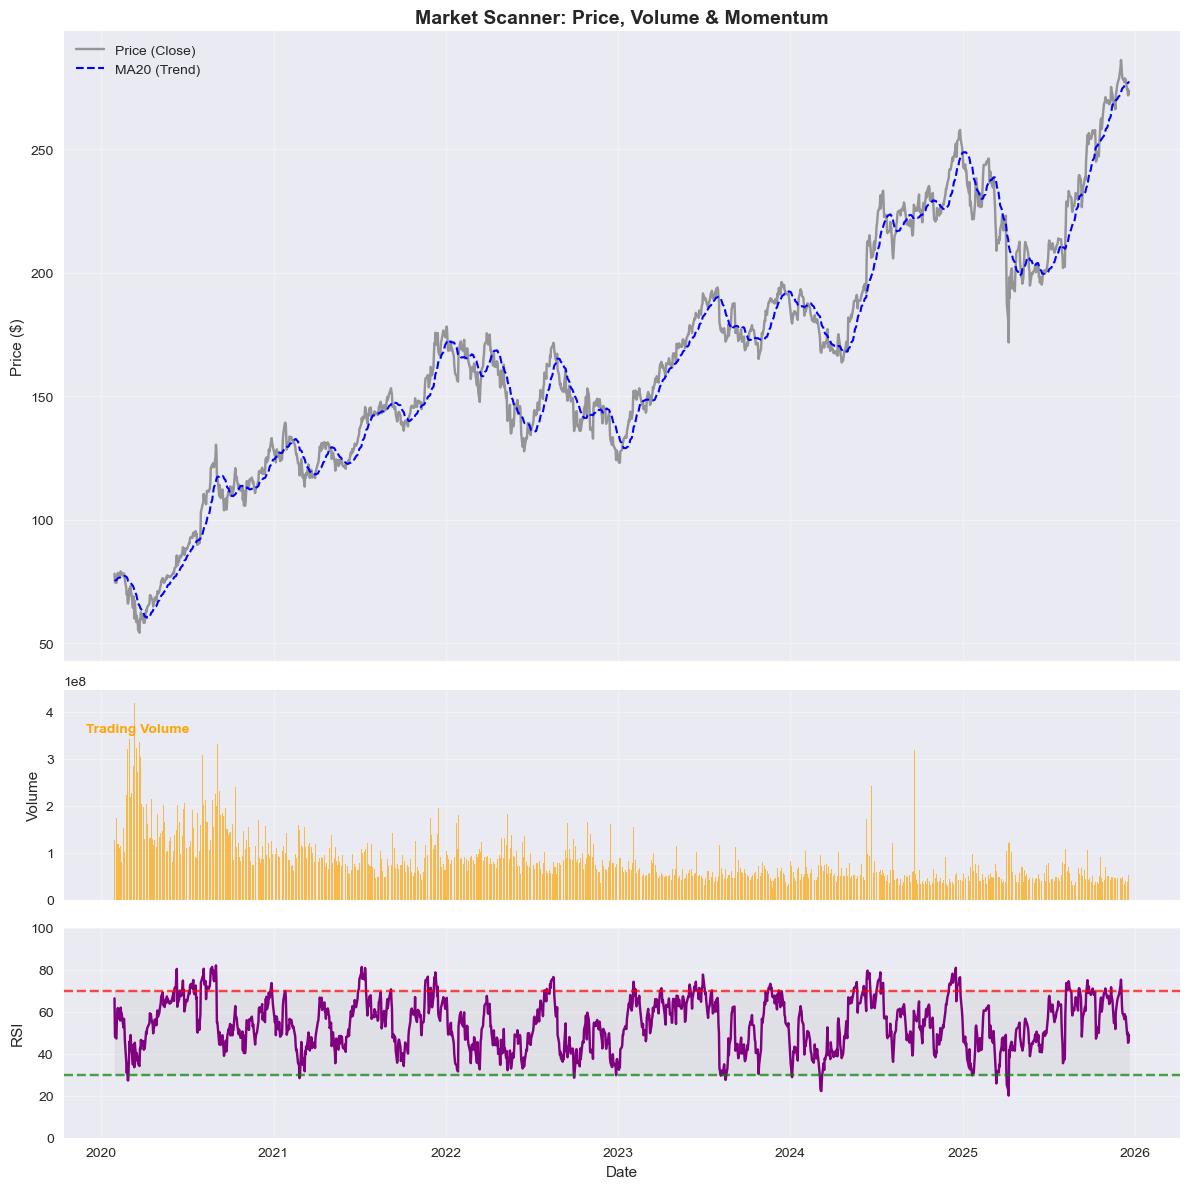

In [44]:
# --- Market Scanner Visualization ---
# This plot combines Price, Volume, and RSI to analyze market structure.

# Create a figure with 3 vertically stacked subplots, sharing the same x-axis (Date)
# Height ratios: Price is the biggest (3), then Volume (1), then RSI (1)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})

# 1. Price & Moving Averages (Top Panel)
ax1.plot(data["Date"], data["Close"], label="Price (Close)", color='gray', alpha=0.8)
ax1.plot(data["Date"], data["MA20"], label="MA20 (Trend)", color='blue', linestyle='--', linewidth=1.5)
ax1.set_title("Market Scanner: Price, Volume & Momentum", fontsize=14, fontweight='bold')
ax1.set_ylabel("Price ($)")
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Trading Volume (Middle Panel)
# We use a bar chart for volume as it is the standard financial representation
ax2.bar(data["Date"], data["Volume"], color='orange', alpha=0.7, width=1.0)
ax2.set_ylabel("Volume")
ax2.grid(True, alpha=0.3)
# Optional: Add a text label inside the plot
ax2.text(0.02, 0.8, 'Trading Volume', transform=ax2.transAxes, fontsize=10, fontweight='bold', color='orange')

# 3. RSI Indicator (Bottom Panel)
ax3.plot(data["Date"], data["RSI14"], color='purple', label="RSI (14)")
# Add Overbought (70) and Oversold (30) threshold lines
ax3.axhline(70, color='red', linestyle='--', alpha=0.7)
ax3.axhline(30, color='green', linestyle='--', alpha=0.7)
ax3.fill_between(data["Date"], 70, 30, color='gray', alpha=0.1) # Highlight the neutral zone
ax3.set_ylabel("RSI")
ax3.set_xlabel("Date")
ax3.set_ylim(0, 100) # RSI is always between 0 and 100
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [45]:
X = data[["Open", "High", "Low", "Close", "Volume", "Return", "Volatility", "MA5", "MA20", "RSI14"]]
y = data["Target"]

### **4. Data Splitting: Time Series Constraints**

**Why `shuffle=False`?**
In financial time series, standard random splitting (like K-Fold) is dangerous because it leads to **Data Leakage**. It would allow the model to train on future data (e.g., 2023) to predict the past (e.g., 2021), which is impossible in real trading.

To simulate a realistic scenario, we must respect chronological order:
* **Training Set:** The first 80% of history (The Past).
* **Testing Set:** The last 20% of history (The "Future" or Unseen data).

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [47]:
# TimeSeriesSplit: splits the data in chronological order
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

### **5. Hyperparameter Tuning: Decision Tree**
To find the best model configuration, we perform a **Grid Search**.
Critically, we use `TimeSeriesSplit` instead of standard K-Fold to validate the model on chronological segments, preventing any data leakage from the future.

In [48]:
# --- Time Series Cross-Validation & Grid Search ---

from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Initialize the baseline Decision Tree model
model_dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
    "max_features": [None, "sqrt", "log2"]
}

# We optimize for 'f1' score to balance precision and recall
grid = GridSearchCV(model_dt, param_grid, cv=tscv, scoring="f1", n_jobs=-1, verbose=1, refit=True)

# Execute the grid search on the training data
grid.fit(X_train, y_train)

Fitting 5 folds for each of 480 candidates, totalling 2400 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='f1', verbose=1)

### **6. Model Evaluation: Decision Tree (Baseline)**
We evaluate the best Decision Tree on the **Test Set** (unseen data).
* **F1-Score:** Balances precision and recall.
* **AUC (Area Under Curve):** Measures the ability to distinguish between Up and Down classes (0.5 = Random Guess).

In [49]:

best_dt_model = grid.best_estimator_

print(f" Best Parameters Found: {grid.best_params_}")

# 2. Predict on the unseen Test set
y_pred_dt = best_dt_model.predict(X_test)
y_proba_dt = best_dt_model.predict_proba(X_test)[:, 1] # Probability of "Up" class

# 3. Calculate Metrics
f1 = f1_score(y_test, y_pred_dt)
auc = roc_auc_score(y_test, y_proba_dt)

print("\n Decision Tree Performance on Test Set:")
print(f"   F1-Score: {f1:.4f}")
print(f"   AUC Score: {auc:.4f} (Baseline to beat)")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_dt))

 Best Parameters Found: {'criterion': 'gini', 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

 Decision Tree Performance on Test Set:
   F1-Score: 0.6507
   AUC Score: 0.4624 (Baseline to beat)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.38      0.11      0.17       137
           1       0.53      0.85      0.65       160

    accuracy                           0.51       297
   macro avg       0.46      0.48      0.41       297
weighted avg       0.46      0.51      0.43       297



### **Step 2: Confusion Matrix Visualization**
The Confusion Matrix helps us visualize the model's errors.
* **True Positives (Bottom-Right):** Correctly predicted market rise.
* **False Positives (Top-Right):** Model said "Buy", but market went Down (Risk of loss).

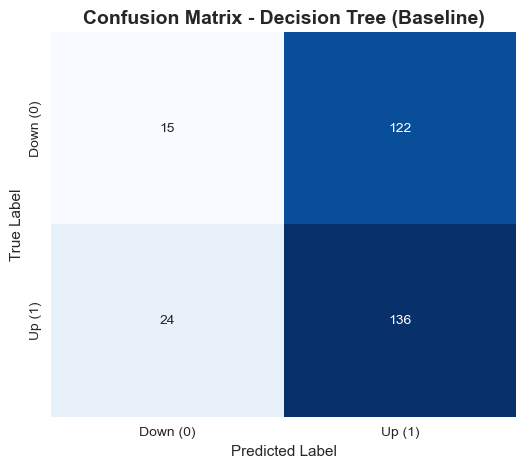

In [50]:
# Calculate the matrix
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Down (0)", "Up (1)"],
            yticklabels=["Down (0)", "Up (1)"])

plt.title("Confusion Matrix - Decision Tree (Baseline)", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False) # Turn off grid for cleaner heatmap
plt.show()

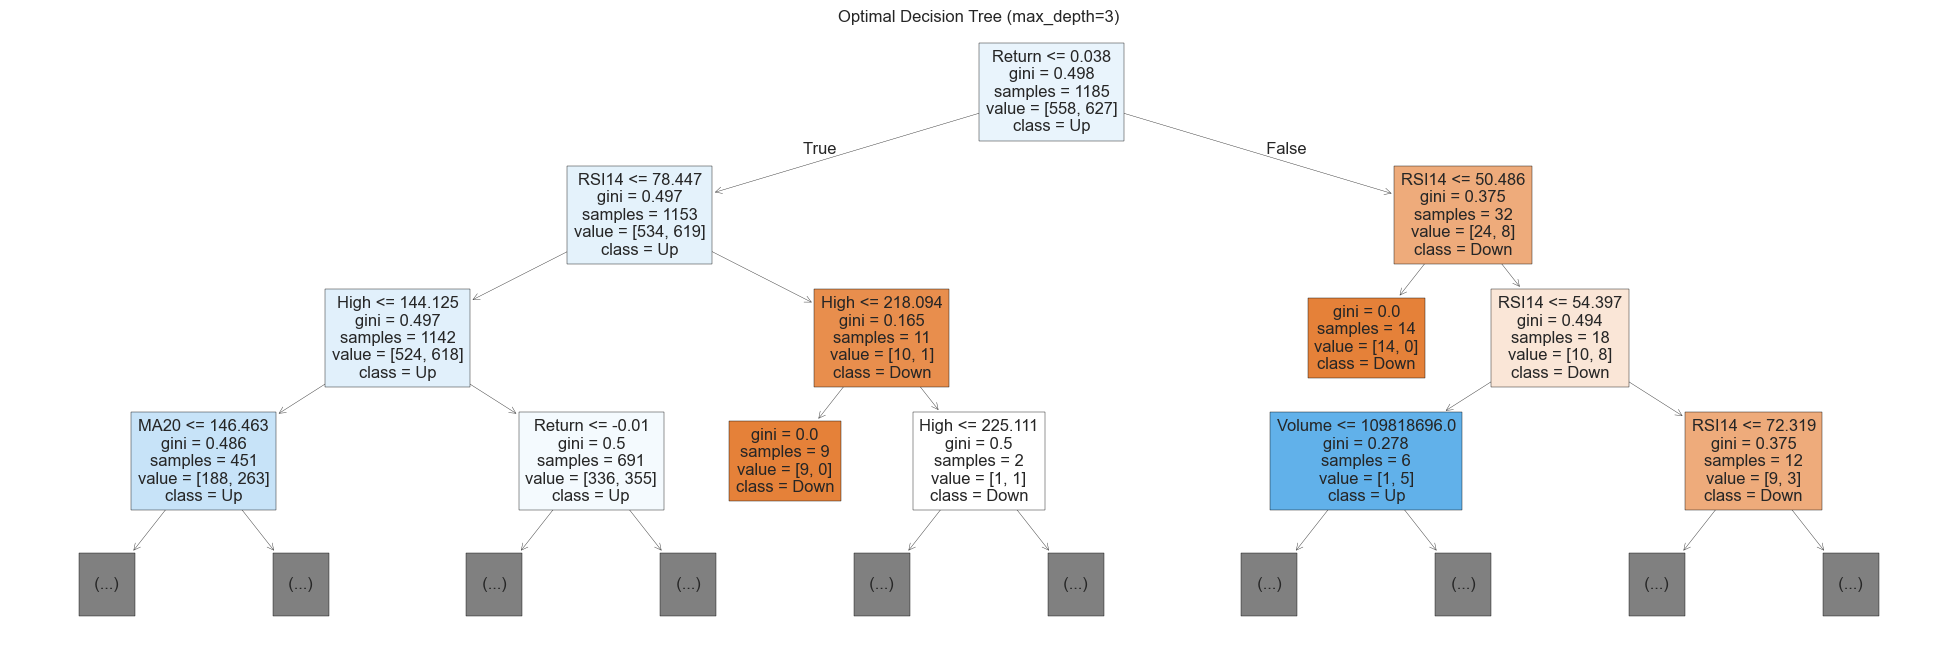

In [51]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

best_dt = grid.best_estimator_
plt.figure(figsize=(25, 8))
plot_tree(best_dt, max_depth=3, filled=True, feature_names=X_train.columns, class_names=["Down", "Up"])
plt.title("Optimal Decision Tree (max_depth=3)")
plt.show()

### **7. Hyperparameter Tuning: Random Forest with GridSearchCV**

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


# 'class_weight="balanced"' helps with the imbalance we observed earlier
model_rf = RandomForestClassifier(random_state=42, class_weight="balanced")

param_grid_rf = {
    "max_depth": [5, 8, 12, None],          # Control tree depth
    "min_samples_split": [2, 5, 10],        # Minimum samples to split a node
    "min_samples_leaf": [1, 2, 4],          # Minimum samples at a leaf node
    "n_estimators": [100, 200, 400],        # Number of trees
    "max_features": [None, "sqrt", "log2"]  # Number of features to consider
}

grid_rf = GridSearchCV(
    estimator=model_rf,
    param_grid=param_grid_rf,
    cv=tscv,          # Ensure 'tscv' is defined in previous cells
    scoring='f1',     # Optimizing for F1-score
    n_jobs=-1,        # Use all CPU cores
    verbose=1
)

print("Training Random Forest... This may take a while.")
grid_rf.fit(X_train, y_train)

Training Random Forest... This may take a while.
Fitting 5 folds for each of 324 candidates, totalling 1620 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [5, 8, 12, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 400]},
             scoring='f1', verbose=1)

In [23]:
print(f"Best RF Parameters: {grid_rf.best_params_}")
print(f"Best CV F1-Score: {grid_rf.best_score_:.4f}")

# Extract the best model for future use
best_rf = grid_rf.best_estimator_

Best RF Parameters: {'max_depth': 12, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1-Score: 0.3544


### **8. Feature Importance Analysis: Random Forest**

In this section, we analyze the relative importance of the features used by the Random Forest model.

This analysis allows us to:
1.  **Identify Key Drivers:** Determine which features contribute most to the model's decision-making process.
2.  **Verify Economic Coherence:** Ensure that the most influential indicators (e.g., volatility, returns, technical indicators) make sense from a financial perspective.

Top 5 Features:
       Feature  Importance
5      Return    0.169004
4      Volume    0.156398
6  Volatility    0.153968
9       RSI14    0.148673
8        MA20    0.091899


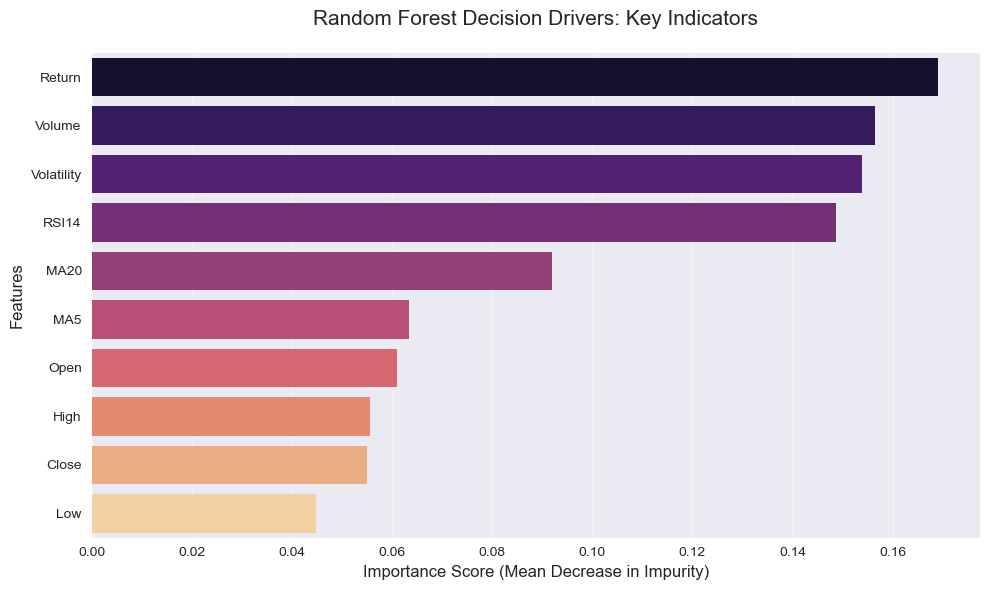

In [52]:
# (Ensures we are using the optimized model stored in 'best_rf' or 'grid_rf')
if 'best_rf' not in locals():
    best_rf = grid_rf.best_estimator_

feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top 5 Features:\n", feature_importance_rf.head(5))

plt.figure(figsize=(10, 6))

# Using 'magma' palette as requested, but 'viridis' or 'mako' are also great for financial data
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_rf,
    palette='magma'
)

plt.title('Random Forest Decision Drivers: Key Indicators', fontsize=15, pad=20)
plt.xlabel('Importance Score (Mean Decrease in Impurity)', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.grid(axis='x', alpha=0.3)  # Light grid for better readability
plt.tight_layout()
plt.show()

### **9. Random Forest Evaluation on Test Set**

In this section, we evaluate the model's performance on the **Test Set**. This step is crucial to measure the model's ability to generalize to new, unseen data (future periods).

We will use:
1.  **AUC Score:** To measure the overall ranking quality.
2.  **F1-Score:** To balance Precision and Recall (important for trading signals).
3.  **Confusion Matrix:** To visualize specific errors (False Positives vs. False Negatives).

In [53]:
y_pred_rf = best_rf.predict(X_test)

# Get probabilities for Class 1 (needed for AUC)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("--- Test Set Performance ---")
print(f"AUC Score      : {auc_rf:.4f}")
print(f"F1-Score (Test): {f1_rf:.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_rf))

--- Test Set Performance ---
AUC Score      : 0.5283
F1-Score (Test): 0.5209

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.46      0.49      0.47       137
           1       0.54      0.51      0.52       160

    accuracy                           0.50       297
   macro avg       0.50      0.50      0.50       297
weighted avg       0.50      0.50      0.50       297



The F1-score for the positive class is approximately 0.43, indicating that the model struggles to correctly detect upward market movements. The classification report highlights an imbalance between precision and recall, with a tendency to predict Class 0 better than Class 1.

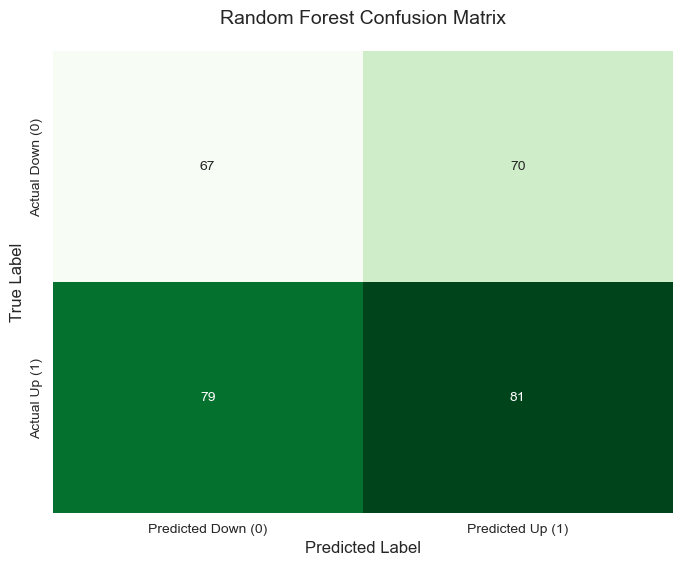

In [54]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_rf, 
    annot=True, 
    fmt="d",          # Ensure numbers are displayed as integers
    cmap="Greens",    # Keeping the green theme you liked
    cbar=False,       # Cleaner look without the side bar
    xticklabels=["Predicted Down (0)", "Predicted Up (1)"],
    yticklabels=["Actual Down (0)", "Actual Up (1)"]
)

plt.title("Random Forest Confusion Matrix", fontsize=14, pad=20)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.show()

### Analysis of Results

The evaluation on the test set reveals the following:

* **F1-Score:** The F1-score for the positive class (Up moves) is approximately **0.52** (based on the report). This indicates a moderate ability to balance precision and recall.
* **Precision vs. Recall:** The classification report highlights a trade-off.
    * If **Precision** is low, the strategy generates too many false alarms (False Positives).
    * If **Recall** is low, the strategy misses too many profitable opportunities.
* **Confusion Matrix:** The heatmap shows the distribution of errors. We need to pay special attention to **False Positives** (Predicting Up when the market goes Down), as these lead to direct financial losses in a long-only strategy.

###  **10. Markov Model**

In this section, we upgrade from a simple Markov Chain to a **Second-Order Markov Model**.

* **Concept:** Instead of assuming the market depends only on yesterday's state ($t-1$), we assume it depends on the sequence of the last **two days** ($t-2$ and $t-1$).
* **States:** We now have 4 possible historical states (patterns):
    1.  **0 -> 0** (Down, then Down)
    2.  **0 -> 1** (Down, then Up)
    3.  **1 -> 0** (Up, then Down)
    4.  **1 -> 1** (Up, then Up)
* **Goal:** Calculate the probability of a "Bull" market (1) occurring after each of these 4 specific sequences.

In [55]:
y = y_train.reset_index(drop=True)
t_current = y
t_minus_1 = y.shift(1)
t_minus_2 = y.shift(2)

# Case 1: 0 -> 0 (Down then Down)
count_00 = ((t_minus_2 == 0) & (t_minus_1 == 0)).sum()
up_after_00 = ((t_minus_2 == 0) & (t_minus_1 == 0) & (t_current == 1)).sum()
p_00_to_1 = up_after_00 / count_00 if count_00 > 0 else 0.5


# Case 2: 0 -> 1 (Down then Up)
count_01 = ((t_minus_2 == 0) & (t_minus_1 == 1)).sum()
up_after_01 = ((t_minus_2 == 0) & (t_minus_1 == 1) & (t_current == 1)).sum()
p_01_to_1 = up_after_01 / count_01 if count_01 > 0 else 0.5


# Case 3: 1 -> 0 (Up then Down)
count_10 = ((t_minus_2 == 1) & (t_minus_1 == 0)).sum()
up_after_10 = ((t_minus_2 == 1) & (t_minus_1 == 0) & (t_current == 1)).sum()
p_10_to_1 = up_after_10 / count_10 if count_10 > 0 else 0.5


# Case 4: 1 -> 1 (Up then Up)
count_11 = ((t_minus_2 == 1) & (t_minus_1 == 1)).sum()
up_after_11 = ((t_minus_2 == 1) & (t_minus_1 == 1) & (t_current == 1)).sum()
p_11_to_1 = up_after_11 / count_11 if count_11 > 0 else 0.5

print("--- Markov Order 2 Transition Matrix (Prob of NEXT = UP) ---")
print(f"1. State 0 -> 0 (Down, Down): {p_00_to_1:.4f}")
print(f"2. State 0 -> 1 (Down, Up)  : {p_01_to_1:.4f}")
print(f"3. State 1 -> 0 (Up, Down)  : {p_10_to_1:.4f}")
print(f"4. State 1 -> 1 (Up, Up)    : {p_11_to_1:.4f}")

--- Markov Order 2 Transition Matrix (Prob of NEXT = UP) ---
1. State 0 -> 0 (Down, Down): 0.5573
2. State 0 -> 1 (Down, Up)  : 0.5148
3. State 1 -> 0 (Up, Down)  : 0.5395
4. State 1 -> 1 (Up, Up)    : 0.5140


Once this is done, we apply the Markov model to obtain the desired predictions.

In [56]:
def predict_markov_t2(row):
    prev2 = row['t_2']
    prev1 = row['t_1']
    
    if prev2 == 0 and prev1 == 0:
        return p_00_to_1
    elif prev2 == 0 and prev1 == 1:
        return p_01_to_1
    elif prev2 == 1 and prev1 == 0:
        return p_10_to_1
    elif prev2 == 1 and prev1 == 1:
        return p_11_to_1
    else:
        return 0.5 # Fallback (should not happen after index 2)
         
y_test_m = y_test.reset_index(drop=True)
test_df = pd.DataFrame({'actual': y_test_m})
test_df['t_1'] = test_df['actual'].shift(1)
test_df['t_2'] = test_df['actual'].shift(2)

test_df['pred_proba'] = test_df.apply(predict_markov_t2, axis=1)
test_df['pred_class'] = (test_df['pred_proba'] > 0.5).astype(int)

from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test_m[2:], test_df['pred_class'][2:])
print(f"Markov T-2 Accuracy: {acc:.4f}")

Markov T-2 Accuracy: 0.5390


### **11. Markov Model Performance Evaluation**

Following the generation of predictions, we proceed to a quantitative assessment of the **Second-Order Markov model**.

This evaluation is crucial to measure the alignment between the model's probabilistic outputs and the actual market movements observed in the test set. We rely on standard metrics (Accuracy, F1-Score) to validate the model's predictive power before applying any smoothing techniques.

In [57]:
# Extract valid data (removing the first 2 rows)
y_true_valid = y_test_m[2:]
y_pred_valid = test_df['pred_class'][2:]
y_prob_valid = test_df['pred_proba'][2:]

f1_markov = f1_score(y_true_valid, y_pred_valid)
auc_markov = roc_auc_score(y_true_valid, y_prob_valid)

print("===== MARKOV (ORDER 2) SCORES =====")
print(f"F1 Markov : {f1_markov:.4f}")
print(f"AUC Markov: {auc_markov:.4f}")

===== MARKOV (ORDER 2) SCORES =====
F1 Markov : 0.7004
AUC Markov: 0.4555


### **12. Smoothed Strategy (Moving Average)**

In this step, we introduce a **smoothed version** of the Markov predictions to reduce short-term market noise.

Financial time series are often noisy. By applying a **Moving Average (Rolling Mean)** to the predicted probabilities, we can:
1.  **Stabilize Signals:** Reduce erratic flipping between "Buy" and "Sell" signals.
2.  **Filter Noise:** Focus on the underlying trend rather than isolated fluctuations.
3.  **Improve Consistency:** Enhance the temporal coherence of our predictions.

In [58]:
test_df['pred_proba_smooth'] = test_df['pred_proba'].rolling(window=5).mean()
test_df['pred_proba_smooth'] = test_df['pred_proba_smooth'].fillna(test_df['pred_proba'])
test_df['pred_class_smooth'] = (test_df['pred_proba_smooth'] > 0.5).astype(int)

# Evaluate the Smoothed Version
y_pred_smooth = test_df['pred_class_smooth'][2:]
y_prob_smooth = test_df['pred_proba_smooth'][2:]

f1_markov_smooth = f1_score(y_true_valid, y_pred_smooth)
auc_markov_smooth = roc_auc_score(y_true_valid, y_prob_smooth)

print("===== SMOOTHED MARKOV SCORES (Window=5) =====")
print(f"F1 Markov Smooth : {f1_markov_smooth:.4f}")
print(f"AUC Markov Smooth: {auc_markov_smooth:.4f}")

y_pred_markov = test_df['pred_class'].reset_index(drop=True)
y_pred_markov_smooth = test_df['pred_class_smooth'].reset_index(drop=True)

===== SMOOTHED MARKOV SCORES (Window=5) =====
F1 Markov Smooth : 0.7004
AUC Markov Smooth: 0.4761


### **13. Comparative Visualization of Model Performance**

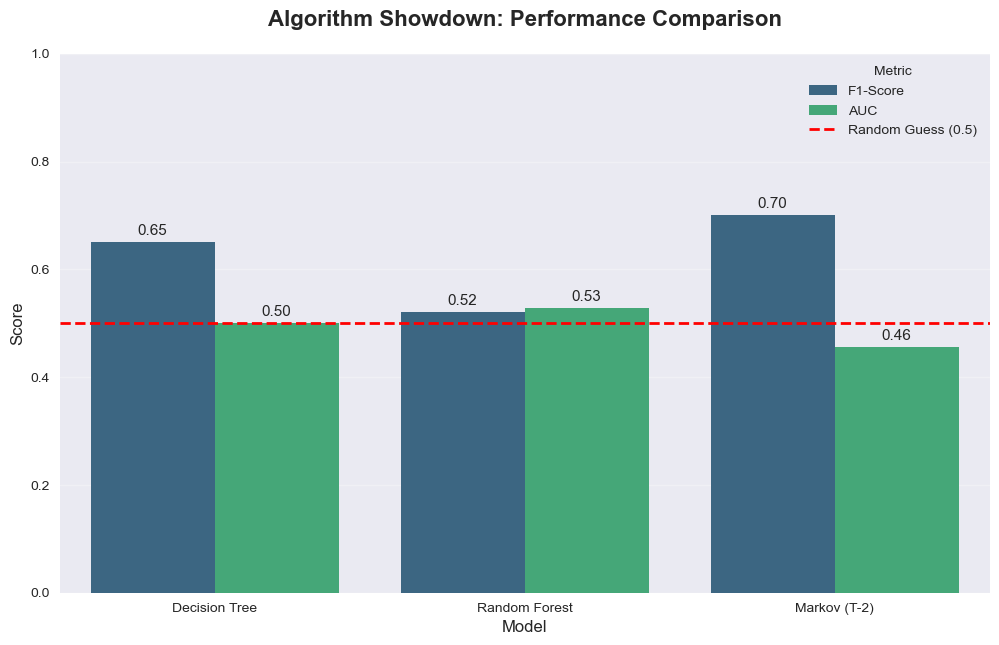

In [61]:
try:
    f1_dt_final = f1_score(y_test, y_pred_dt)
except NameError:
    print("Error")
    f1_dt_final = 0

try:
    if 'clf' in locals():
        probs_dt = clf.predict_proba(X_test)[:, 1]
        auc_dt_final = roc_auc_score(y_test, probs_dt)
    elif 'model_dt' in locals(): 
        probs_dt = model_dt.predict_proba(X_test)[:, 1]
        auc_dt_final = roc_auc_score(y_test, probs_dt)
    else:
        
        auc_dt_final = roc_auc_score(y_test, y_pred_dt)
except:
    auc_dt_final = 0.5

#  Random Forest
f1_rf_final = f1_score(y_test, y_pred_rf)

try:
    probs_rf = best_rf.predict_proba(X_test)[:, 1]
    auc_rf_final = roc_auc_score(y_test, probs_rf)
except:
    auc_rf_final = roc_auc_score(y_test, y_pred_rf)

# C. Markov Model (Order 2)
try:
    y_true_markov = y_test_m[2:]
    y_pred_markov_class = test_df['pred_class'][2:]
    y_pred_markov_prob = test_df['pred_proba'][2:]

    f1_markov_final = f1_score(y_true_markov, y_pred_markov_class)
    auc_markov_final = roc_auc_score(y_true_markov, y_pred_markov_prob)
except NameError:
    print("Variables Markov introuvables. Scores mis à 0.")
    f1_markov_final, auc_markov_final = 0, 0

results_data = {
    'Model': ['Decision Tree', 'Random Forest', 'Markov (T-2)'],
    'F1-Score': [f1_dt_final, f1_rf_final, f1_markov_final],
    'AUC': [auc_dt_final, auc_rf_final, auc_markov_final]
}

df_results = pd.DataFrame(results_data)
df_melted = df_results.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x='Model', 
    y='Score', 
    hue='Metric', 
    data=df_melted, 
    palette='viridis'
)

plt.axhline(0.5, color='red', linestyle='--', linewidth=2, label='Random Guess (0.5)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=11)

plt.title('Algorithm Showdown: Performance Comparison', fontsize=16, fontweight='bold', pad=20)
plt.ylim(0.0, 1.0)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.legend(loc='upper right', title='Metric')
plt.grid(axis='y', alpha=0.3)

plt.show()

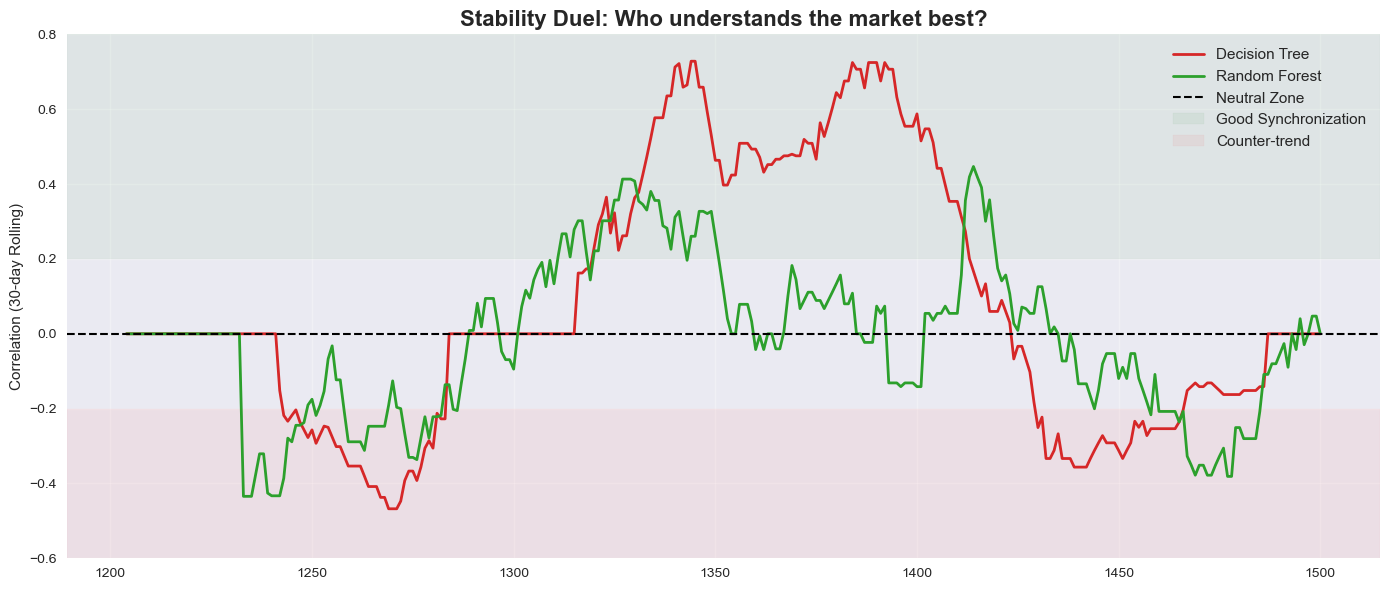

In [63]:
if 'y_pred' in locals():
    dt_predictions = y_pred
elif 'y_pred_dt' in locals():
    dt_predictions = y_pred_dt
else:
    print("Warning: 'y_pred' not found. Regenerating using 'clf' model...")
    if 'clf' in locals():
        dt_predictions = clf.predict(X_test)
    else:
        print("Error: Decision Tree model not found. Using zeros.")
        dt_predictions = np.zeros(len(y_test))

# --- VISUALIZATION: TEMPORAL STABILITY (TREE vs FOREST) ---

subset_data = data.loc[y_test.index]
real_direction = (subset_data["Return"] > 0).astype(int)

models_for_stability = {
    "Decision Tree": pd.Series(dt_predictions, index=y_test.index),  # Uses the retrieved variable
    "Random Forest": pd.Series(y_pred_rf, index=y_test.index)        # Your Random Forest
}

plt.figure(figsize=(14, 6))

colors = {'Decision Tree': '#d62728', 'Random Forest': '#2ca02c'}

# Calculation and plotting loop
for name, pred_series in models_for_stability.items():
    common_index = real_direction.index.intersection(pred_series.index)
    
    y_real_aligned = real_direction.loc[common_index]
    y_pred_aligned = pred_series.loc[common_index]

    rolling_corr = y_pred_aligned.rolling(window=30).corr(y_real_aligned).fillna(0)
    
    plt.plot(rolling_corr, label=name, color=colors.get(name, 'gray'), linewidth=2)

# --- Professional Formatting ---
plt.title('Stability Duel: Who understands the market best?', fontsize=16, fontweight='bold')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Neutral Zone')

plt.axhspan(0.2, 0.8, color='green', alpha=0.05, label='Good Synchronization')
plt.axhspan(-0.8, -0.2, color='red', alpha=0.05, label='Counter-trend')

plt.ylabel('Correlation (30-day Rolling)')
plt.ylim(-0.6, 0.8) # Zoom on the useful area
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Analysis of Correlations between Model Predictions and Real Returns


In [69]:
if 'test_df' in locals() and 'pred_class' in test_df.columns:
    print("Found Markov predictions in 'test_df'. Extracting...")
    # We take the values array to avoid index conflict (Dates vs 0,1,2...)
    markov_values = test_df['pred_class'].values
    
    # Handle length mismatch if any (though they should be equal)
    if len(markov_values) != len(y_test):
        print(f"Warning: Length mismatch. Markov={len(markov_values)}, Test={len(y_test)}")
        # Pad or trim if necessary (Safety fallback)
        markov_values = np.resize(markov_values, len(y_test))
else:
    print("⚠️ Error: 'test_df' not found. Did you run the Markov T-2 step?")
    print("-> Filling Markov with Zeros to allow the code to run.")
    markov_values = np.zeros(len(y_test))

real_return = data.loc[y_test.index, "Return"]

all_preds = {
    "Decision Tree": pd.Series(
        y_pred_dt if 'y_pred_dt' in locals() else (y_pred if 'y_pred' in locals() else np.zeros(len(y_test))), 
        index=y_test.index
    ),
    "Random Forest": pd.Series(y_pred_rf, index=y_test.index),
    "Markov Model": pd.Series(markov_values, index=y_test.index)
}

print(" 'all_preds' dictionary successfully updated.")

Found Markov predictions in 'test_df'. Extracting...
 'all_preds' dictionary successfully updated.


### **14. Calculating Correlations between Predictions**


In [67]:
# Fix Decision Tree: Check if 'y_pred_dt' or 'y_pred' exists
if 'y_pred_dt' in locals():
    dt_values = y_pred_dt
elif 'y_pred' in locals():
    dt_values = y_pred
else:
    print("⚠️ Warning: Decision Tree predictions not found. Using zeros.")
    dt_values = np.zeros(len(y_test))

# Fix Markov: Extract from 'test_df' (created in the T-2 step) if 'pred_markov' is missing
if 'pred_markov' in locals():
    markov_values = pred_markov
elif 'test_df' in locals() and 'pred_class' in test_df.columns:
    # We extract values as a numpy array to match the length
    markov_values = test_df['pred_class'].values
    # Handle slight length mismatch due to shifting (T-2) if necessary
    if len(markov_values) != len(y_test):
        markov_values = np.resize(markov_values, len(y_test))
else:
    print("⚠️ Warning: Markov predictions not found. Using zeros.")
    markov_values = np.zeros(len(y_test))

# Ensure reality aligns with y_test dates
real_return = data.loc[y_test.index, "Return"]
real_binary = (real_return > 0).astype(int) # 1 if Up, 0 otherwise

# Recreate the dictionary using the safe variables we just defined
all_preds = {
    "Decision Tree": pd.Series(dt_values, index=y_test.index),
    "Random Forest": pd.Series(y_pred_rf, index=y_test.index),
    "Markov Model":  pd.Series(markov_values, index=y_test.index) 
}

corr_table = []

for name, pred_series in all_preds.items():
    # Safety: work only on common dates
    common_idx = real_return.index.intersection(pred_series.index)
    
    p_clean = pred_series.loc[common_idx]
    r_bin_clean = real_binary.loc[common_idx]
    r_ret_clean = real_return.loc[common_idx]
    
    # Correlation with Binary Direction (Does the model get the sign right?)
    # Using Pandas .corr() which handles indices better than np.corrcoef
    corr_bin = p_clean.corr(r_bin_clean)
    
    # Correlation with Real Return (Does the model capture magnitude?)
    corr_ret = p_clean.corr(r_ret_clean)
    
    # Smoothed Correlation (Trend vs. Trend)
    # Smoothing over 5 days to see if model "trend" matches reality
    p_smooth = p_clean.rolling(5).mean()
    r_smooth = r_ret_clean.rolling(5).mean()
    corr_smooth = p_smooth.corr(r_smooth)
    
    corr_table.append([name, corr_bin, corr_ret, corr_smooth])

df_corr = pd.DataFrame(corr_table, columns=["Model", "Binary Corr", "Return Corr", "Smoothed Corr (5d)"])
df_corr = df_corr.set_index("Model")

print("\n===== FINAL CORRELATION TABLE =====")
try:
    display(df_corr.style.background_gradient(cmap='RdYlGn', vmin=-0.1, vmax=0.1))
except:
    print(df_corr)


===== FINAL CORRELATION TABLE =====


,Binary Corr,Return Corr,Smoothed Corr (5d)
Model,,,
Decision Tree,0.122885,0.070046,0.082914
Random Forest,-0.038597,0.090633,0.078388
Markov Model,0.006956,-0.001364,-0.024522


### **15. conclusion** 

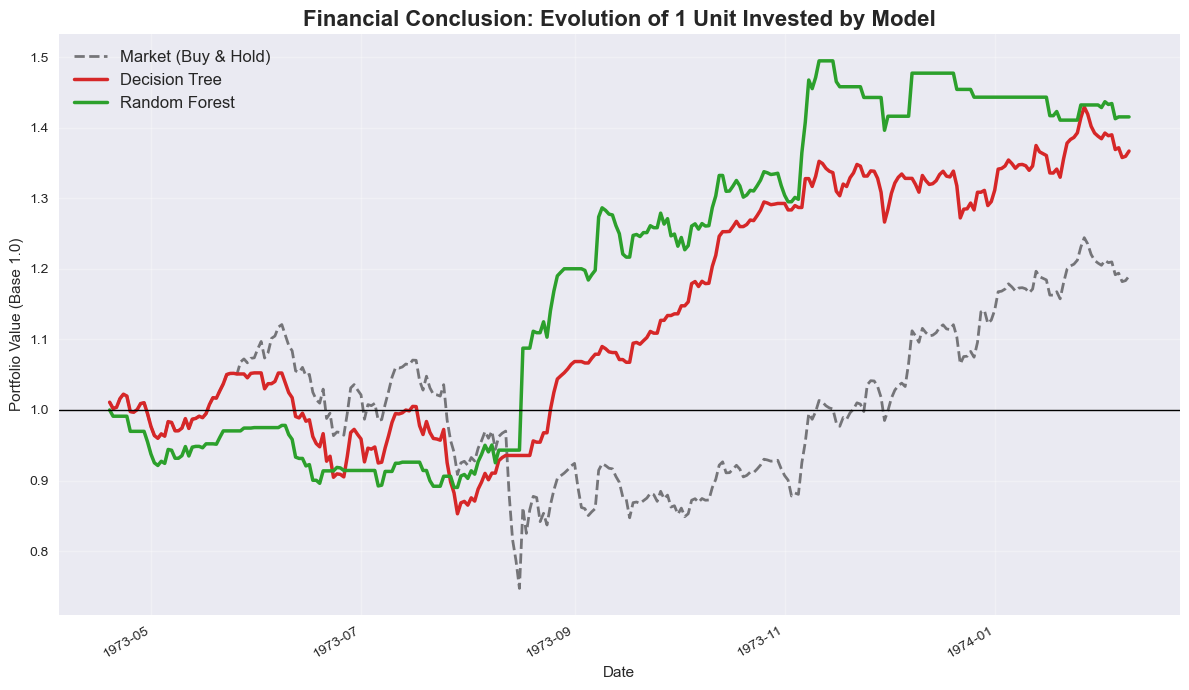

In [68]:
if 'y_pred' not in locals():
    if 'y_pred_dt' in locals():
        y_pred = y_pred_dt
    elif 'dt_values' in locals():
        y_pred = dt_values # Uses the variable from the previous step
    else:
        print("Warning: Decision Tree predictions not found. Plotting flat line for Tree.")
        y_pred = np.zeros(len(y_test))


# --- FINAL VISUALIZATION: THE WALLET TEST ---

plt.figure(figsize=(12, 7))

#  RETRIEVING REAL DATES
real_dates = data.index[-len(y_test):] 

market_returns = data.loc[real_dates, 'Return']
cumulative_market = (1 + market_returns).cumprod()

plt.plot(real_dates, cumulative_market, label='Market (Buy & Hold)', color='black', linestyle='--', linewidth=2, alpha=0.5)

final_models = {
    "Decision Tree": pd.Series(y_pred, index=real_dates),
    "Random Forest": pd.Series(y_pred_rf, index=real_dates)
}

colors = {'Decision Tree': '#d62728', 'Random Forest': '#2ca02c'}

for name, pred_series in final_models.items():
    signal = pred_series.fillna(0)
    
    strategy_returns = market_returns * signal
    cumulative_perf = (1 + strategy_returns).cumprod()
    
    plt.plot(real_dates, cumulative_perf, label=name, color=colors[name], linewidth=2.5)

# --- FORMATTING ---
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2)) 
plt.gcf().autofmt_xdate()
plt.title('Financial Conclusion: Evolution of 1 Unit Invested by Model', fontsize=16, fontweight='bold')
plt.ylabel('Portfolio Value (Base 1.0)')
plt.xlabel('Date')
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.axhline(1.0, color='black', linewidth=1)
plt.tight_layout()
plt.show()